In [ ]:
!pip install -q --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 94.8 MB/s eta 0:00:00


In [2]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import psutil
warnings.filterwarnings('ignore')

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer, TrainingArguments
)
from torch.utils.data import Dataset
from torch.nn.functional import softmax
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# ── GPU Check ──────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [3]:
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv', encoding='latin-1')
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

print(f'Shape  : {df.shape}')
print(f'Classes: {df["label"].value_counts().to_dict()}')
print(f'Spam % : {df["label_num"].mean():.2%}')
df.head()

Shape  : (5572, 3)
Classes: {'ham': 4825, 'spam': 747}
Spam % : 13.41%


,label,text,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


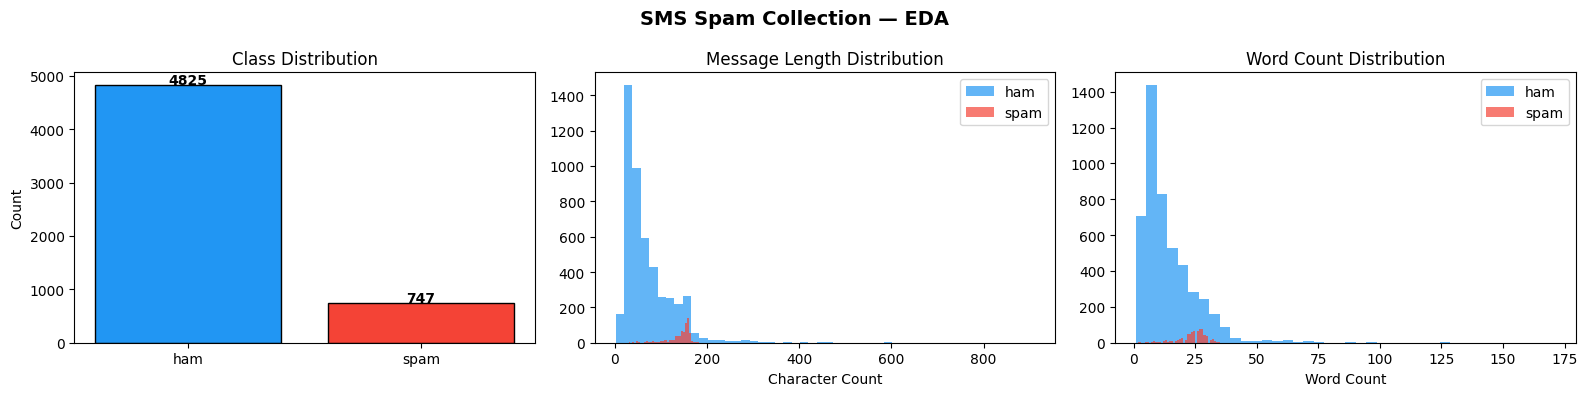


Stats by class:


msg_len                                                word_count        \
        count   mean   std   min    25%    50%    75%    max      count  mean   
label                                                                           
ham    4825.0   71.0  58.0   2.0   33.0   52.0   92.0  910.0     4825.0  14.2   
spam    747.0  138.9  29.2  13.0  132.5  149.0  157.0  224.0      747.0  23.9   

                                           
        std  min   25%   50%   75%    max  
label                                      
ham    11.4  1.0   7.0  11.0  19.0  171.0  
spam    5.8  2.0  22.0  25.0  28.0   35.0

In [4]:
df['msg_len']   = df['text'].apply(len)
df['word_count']= df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('SMS Spam Collection — EDA', fontsize=14, fontweight='bold')

# Class distribution
counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#2196F3','#F44336'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+20, str(v), ha='center', fontweight='bold')

# Message length
for label, color in [('ham','#2196F3'),('spam','#F44336')]:
    axes[1].hist(df[df['label']==label]['msg_len'], bins=50, alpha=0.7, label=label, color=color)
axes[1].set_title('Message Length Distribution')
axes[1].set_xlabel('Character Count')
axes[1].legend()

# Word count
for label, color in [('ham','#2196F3'),('spam','#F44336')]:
    axes[2].hist(df[df['label']==label]['word_count'], bins=40, alpha=0.7, label=label, color=color)
axes[2].set_title('Word Count Distribution')
axes[2].set_xlabel('Word Count')
axes[2].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nStats by class:')
df.groupby('label')[['msg_len','word_count']].describe().round(1)

In [5]:
X = df['text'].tolist()
y = df['label_num'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'Train : {len(X_train)} samples  |  spam: {sum(y_train)/len(y_train):.2%}')
print(f'Val   : {len(X_val)}  samples  |  spam: {sum(y_val)/len(y_val):.2%}')
print(f'Test  : {len(X_test)}  samples  |  spam: {sum(y_test)/len(y_test):.2%}')

Train : 3900 samples  |  spam: 13.41%
Val   : 836  samples  |  spam: 13.40%
Test  : 836  samples  |  spam: 13.40%


In [6]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 128   # SMS messages are short; 128 tokens is more than enough

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

train_enc = tokenizer(X_train, truncation=True, padding=True, max_length=MAX_LEN)
val_enc   = tokenizer(X_val,   truncation=True, padding=True, max_length=MAX_LEN)
test_enc  = tokenizer(X_test,  truncation=True, padding=True, max_length=MAX_LEN)

print(f'Tokenizer : {MODEL_NAME}')
print(f'Max length: {MAX_LEN} tokens')
print(f'Vocab size: {tokenizer.vocab_size:,}')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer : distilbert-base-uncased
Max length: 128 tokens
Vocab size: 30,522


In [7]:
class SMSDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_ds = SMSDataset(train_enc, y_train)
val_ds   = SMSDataset(val_enc,   y_val)
test_ds  = SMSDataset(test_enc,  y_test)
print('Datasets ready.')

Datasets ready.


In [8]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0:'ham', 1:'spam'},
    label2id={'ham':0, 'spam':1}
)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model      : {MODEL_NAME}')
print(f'Parameters : {total:,} total  |  {trainable:,} trainable')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model      : distilbert-base-uncased
Parameters : 66,955,010 total  |  66,955,010 trainable


In [9]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    _, _, f1, _ = precision_recall_fscore_support(labels, preds, average='binary', zero_division=0)
    return {'f1': f1}   # ← only return F1

training_args = TrainingArguments(
    output_dir                  = '/kaggle/working/distilbert-sms',
    num_train_epochs            = 3,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    learning_rate               = 2e-5,
    warmup_steps                = 100,
    weight_decay                = 0.01,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1',
    greater_is_better           = True,    # ← add this line
    logging_dir                 = '/kaggle/working/logs',
    logging_steps               = 50,
    fp16                        = torch.cuda.is_available(),
    report_to                   = 'none',
    dataloader_num_workers      = 2,
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    compute_metrics = compute_metrics,
)

print('Fine-tuning DistilBERT on Kaggle P100...')
t0 = time.time()
trainer.train()
print(f'Training done in {(time.time()-t0)/60:.1f} minutes')

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Fine-tuning DistilBERT on Kaggle P100...


Epoch,Training Loss,Validation Loss,F1
1,1.089699,0.278798,0.833333
2,0.188937,0.067231,0.960352
3,0.072095,0.057826,0.973214


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training done in 1.2 minutes


In [10]:
# ── Predictions on held-out TEST set ──────────────────────
raw       = trainer.predict(test_ds)
logits    = raw.predictions
y_pred    = np.argmax(logits, axis=-1)
y_prob    = softmax(torch.tensor(logits).float(), dim=1).numpy()[:, 1]

print('=' * 55)
print('        CLASSIFICATION REPORT — TEST SET')
print('=' * 55)
print(classification_report(y_test, y_pred, target_names=['Ham (0)', 'Spam (1)']))
print(f'AUC-ROC : {roc_auc_score(y_test, y_prob):.4f}')

        CLASSIFICATION REPORT — TEST SET
              precision    recall  f1-score   support

     Ham (0)       0.99      1.00      1.00       724
    Spam (1)       1.00      0.96      0.98       112

    accuracy                           1.00       836
   macro avg       1.00      0.98      0.99       836
weighted avg       1.00      1.00      1.00       836

AUC-ROC : 0.9990


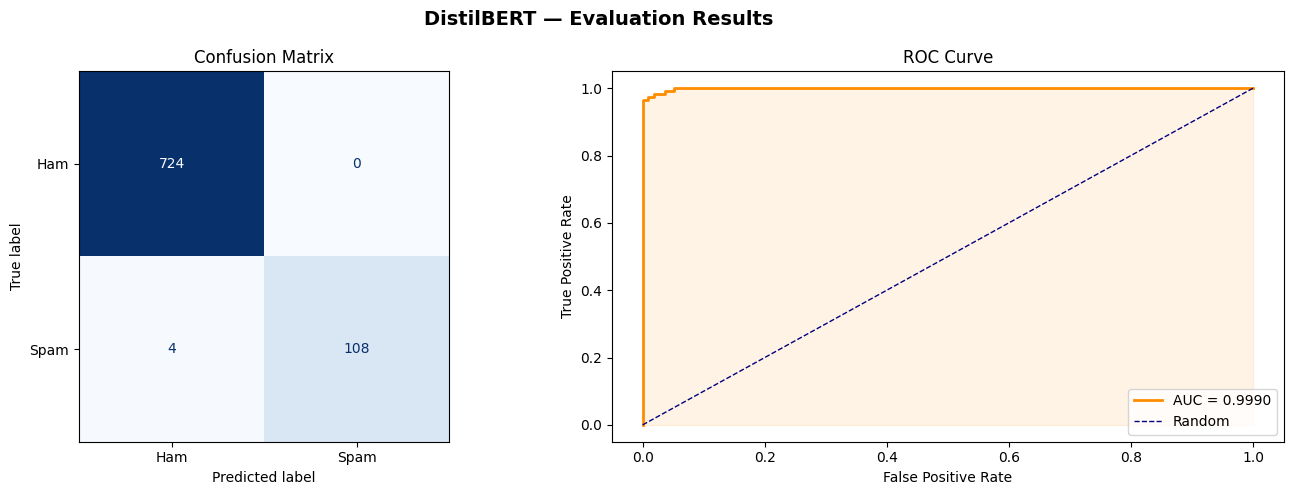

In [11]:
auc = roc_auc_score(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DistilBERT — Evaluation Results', fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Ham','Spam']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1], 'navy', lw=1, linestyle='--', label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
axes[1].set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC Curve')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('/kaggle/working/evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
from sklearn.metrics import f1_score, classification_report

raw    = trainer.predict(test_ds)
y_pred = np.argmax(raw.predictions, axis=-1)

f1 = f1_score(y_test, y_pred)

print('=' * 40)
print(f'  PRIMARY METRIC — F1 Score (Spam)')
print('=' * 40)
print(f'  F1 = {f1:.4f}  ({f1*100:.2f}%)')
print('=' * 40)
print()
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

  PRIMARY METRIC — F1 Score (Spam)
  F1 = 0.9818  (98.18%)

              precision    recall  f1-score   support

         Ham       0.99      1.00      1.00       724
        Spam       1.00      0.96      0.98       112

    accuracy                           1.00       836
   macro avg       1.00      0.98      0.99       836
weighted avg       1.00      1.00      1.00       836



In [13]:
from transformers import pipeline as hf_pipeline

classifier = hf_pipeline(
    'text-classification',
    model=model, tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

test_msgs = [
    "Congratulations! You've won a FREE iPhone. Click here NOW!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your bank account is suspended. Call 0800-FREE now!",
    "Can you send me the notes from today's class?",
    "Win £1000 cash! Text WIN to 86888. Ts&Cs apply.",
    "Mum says dinner is ready, come home!",
]

print('Inference Results:')
print('-' * 65)
for msg in test_msgs:
    res   = classifier(msg, truncation=True, max_length=MAX_LEN)[0]
    label = res['label'].upper()
    score = res['score']
    icon  = 'SPAM' if label == 'SPAM' else 'HAM '
    short = msg[:55] + '...' if len(msg) > 55 else msg
    print(f'{icon} ({score:.2%})  →  {short}')

Inference Results:
-----------------------------------------------------------------
SPAM (95.76%)  →  Congratulations! You've won a FREE iPhone. Click here N...
HAM  (99.69%)  →  Hey, are we still meeting for lunch tomorrow?
SPAM (98.46%)  →  URGENT: Your bank account is suspended. Call 0800-FREE ...
HAM  (98.92%)  →  Can you send me the notes from today's class?
SPAM (99.48%)  →  Win £1000 cash! Text WIN to 86888. Ts&Cs apply.
HAM  (99.69%)  →  Mum says dinner is ready, come home!


In [14]:
SAVE_PATH = '/kaggle/working/sms_spam_distilbert'
model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f' Model saved to {SAVE_PATH}')
print('   Files saved:')
for f in os.listdir(SAVE_PATH):
    size = os.path.getsize(f'{SAVE_PATH}/{f}')/1e6
    print(f'   {f:35s}  {size:.1f} MB')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 Model saved to /kaggle/working/sms_spam_distilbert
   Files saved:
   config.json                          0.0 MB
   tokenizer_config.json                0.0 MB
   tokenizer.json                       0.7 MB
   model.safetensors                    267.8 MB


In [16]:
import shutil
shutil.make_archive('/kaggle/working/sms_model', 'zip', '/kaggle/working/sms_spam_distilbert')
print('Done — download sms_model.zip from Output tab')

Done — download sms_model.zip from Output tab
